
# Olist E-Commerce Data Analytics Project

## Notebook 4: RFM Customer Segmentation

### Objective

The objective of this notebook is to segment customers based on their purchasing behavior using RFM (Recency, Frequency, Monetary) Analysis.

RFM segmentation helps businesses identify loyal customers, high-value customers, inactive customers, and customers who require retention strategies.

### Import Libraries

In [3]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 3.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.2 MB 3.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 6.2 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 7.1 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 7.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 7.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 5.8 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 2.8 MB/s eta 0:00:14
   - -----------------


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

### Load Clean Data 

In [5]:
clean_path = r"C:\Users\ASUS\OneDrive\Desktop\E commerce Analytics Project\Data\Cleaned"

customers = pd.read_csv(f"{clean_path}/customers_clean.csv")

orders = pd.read_csv(f"{clean_path}/orders_clean.csv")

order_payments = pd.read_csv(f"{clean_path}/order_payments_clean.csv")

### Date Conversion

In [6]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

## Creating the RFM Base Table

RFM Analysis requires customer purchase history.

The following steps merge customer, order, and payment data to calculate:

- Recency
- Frequency
- Monetary Value

### Merging Tables

In [7]:
rfm = (
    orders
    .merge(customers,on="customer_id")
    .merge(order_payments,on="order_id")
)

rfm.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12


### Reference Date

In [9]:
snapshot_date = (
    rfm["order_purchase_timestamp"].max()
    +
    pd.Timedelta(days=1)
)

print("Snapshot Date :", snapshot_date.date())

Snapshot Date : 2018-10-18


### Creating RFM Table

In [37]:
rfm_table = (
    rfm
    .groupby("customer_unique_id")
    .agg(
        Recency=(
            "order_purchase_timestamp",
            lambda x:(snapshot_date-x.max()).days
        ),

        Frequency=(
            "order_id",
            "nunique"
        ),

        Monetary=(
            "payment_value",
            "sum"
        )
    )
    .reset_index()
)

rfm_table.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


### Dataset Information

In [11]:
rfm_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96095 entries, 0 to 96094
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96095 non-null  object 
 1   Recency             96095 non-null  int64  
 2   Frequency           96095 non-null  int64  
 3   Monetary            96095 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.9+ MB


In [12]:
rfm_table.describe()

,Recency,Frequency,Monetary
count,96095.000000,96095.000000,96095.000000
mean,288.730756,1.034809,166.594226
std,153.407846,0.214385,231.428912
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


### Missing Values

In [13]:
rfm_table.isnull().sum()

customer_unique_id    0
Recency               0
Frequency             0
Monetary              0
dtype: int64

### Distribution Of Recency

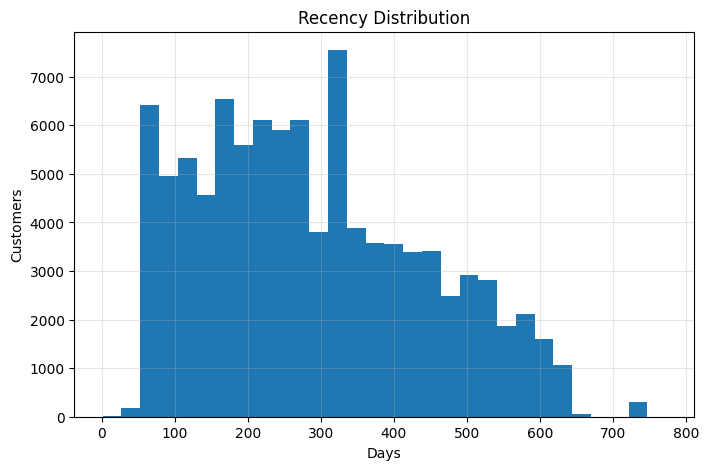

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    rfm_table["Recency"],
    bins=30
)

plt.title("Recency Distribution")

plt.xlabel("Days")

plt.ylabel("Customers")

plt.grid(alpha=0.3)

plt.show()

### Distribution Of Frequency

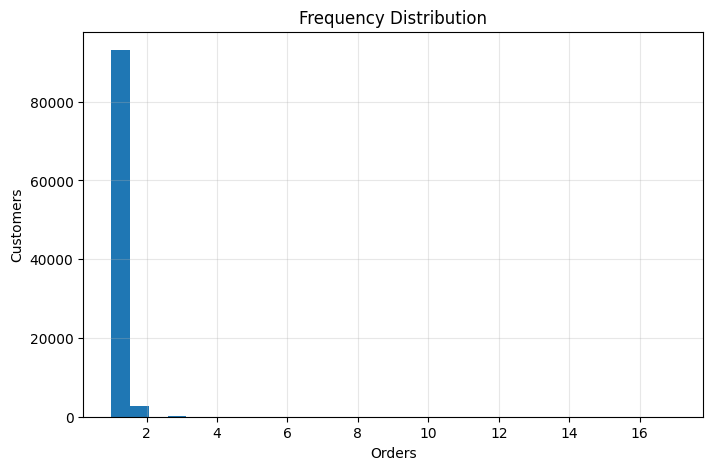

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    rfm_table["Frequency"],
    bins=30
)

plt.title("Frequency Distribution")

plt.xlabel("Orders")

plt.ylabel("Customers")

plt.grid(alpha=0.3)

plt.show()

In [16]:
### Distribution Of Monetary

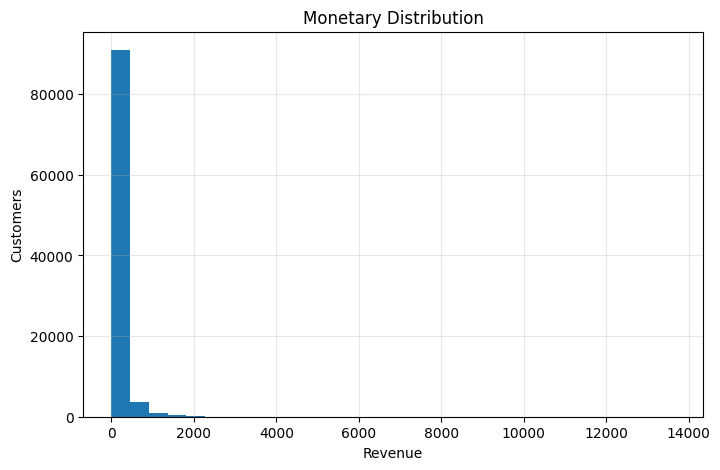

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    rfm_table["Monetary"],
    bins=30
)

plt.title("Monetary Distribution")

plt.xlabel("Revenue")

plt.ylabel("Customers")

plt.grid(alpha=0.3)

plt.show()

### Business Insight

The RFM variables show significant variation among customers.

Some customers purchase frequently and spend large amounts, while many customers purchase only once.

This indicates that customer segmentation can provide valuable business insights.

### Feature Scaling

In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_table[
        ["Recency","Frequency","Monetary"]
    ]
)

### Elbow Method

In [20]:
inertia=[]

for i in range(2,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

### Plotting Elbow

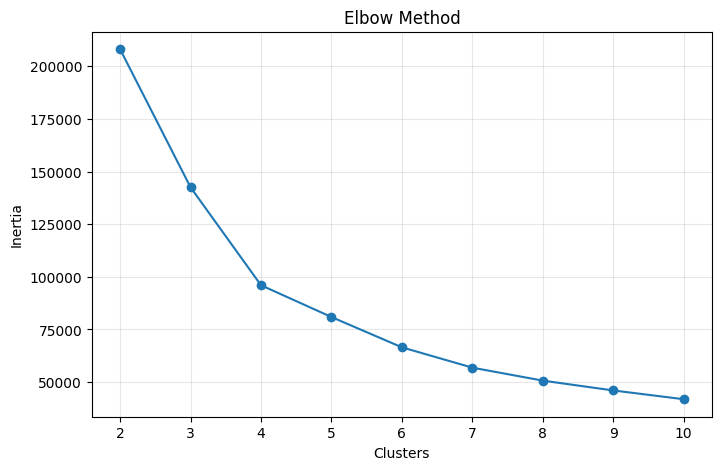

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.show()

### Silhouette Score

The complete dataset contained around 99,000 customers. Since silhouette score is computationally expensive for large datasets, I evaluated cluster quality using a representative random sample of 10,000 customers, which is a common industry practice

In [23]:
scores = []

sample = rfm_table.sample(
    n=10000,
    random_state=42
)

sample_scaled = scaler.fit_transform(
    sample[["Recency", "Frequency", "Monetary"]]
)

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(sample_scaled)

    score = silhouette_score(
        sample_scaled,
        labels
    )

    scores.append(score)

for k, score in zip(range(2, 11), scores):
    print(f"K = {k} : {score:.4f}")

K = 2 : 0.7329
K = 3 : 0.4529
K = 4 : 0.4819
K = 5 : 0.4982
K = 6 : 0.4402
K = 7 : 0.4414
K = 8 : 0.4510
K = 9 : 0.3885
K = 10 : 0.3944


### Choose K = 4

In [24]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm_table["Cluster"]=kmeans.fit_predict(
    rfm_scaled
)

In [32]:
cluster_names = {
    0: "Inactive Customers",
    1: "High Value Customers",
    2: "Regular Customers",
    3: "Recent Customers"
}

rfm_table["Customer_Segment"] = rfm_table["Cluster"].map(cluster_names)

rfm_table.head()

,customer_unique_id,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,3,Recent Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,3,Recent Customers
2,0000f46a3911fa3c0805444483337064,586,1,86.22,0,Inactive Customers
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,0,Inactive Customers
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,0,Inactive Customers


### Cluster Summary

In [33]:
cluster_summary = (
    rfm_table
    .groupby("Cluster")
    .agg({
        "Recency":"mean",
        "Frequency":"mean",
        "Monetary":"mean"
    })
)

cluster_summary.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,438.80,1.00,134.93
1,289.49,1.02,1196.23
2,269.31,2.12,290.31
3,178.36,1.00,135.16


### Cluster Size

In [34]:
rfm_table["Cluster"].value_counts()

Cluster
3    52056
0    38655
2     2962
1     2422
Name: count, dtype: int64

### Cluster Visualization

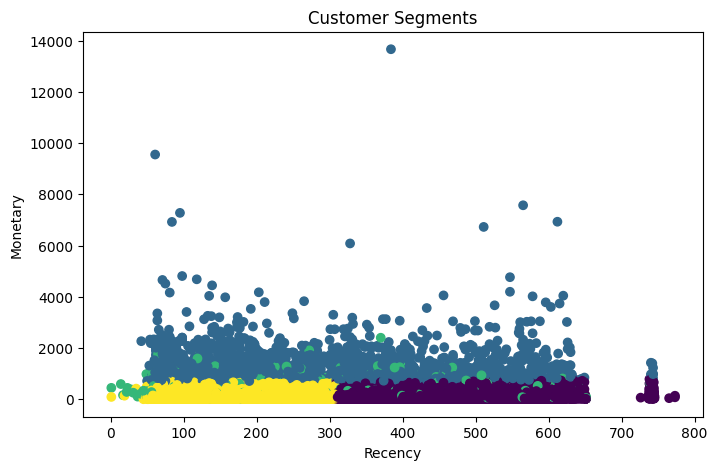

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm_table["Recency"],
    rfm_table["Monetary"],
    c=rfm_table["Cluster"]
)

plt.title("Customer Segments")

plt.xlabel("Recency")

plt.ylabel("Monetary")

plt.show()

## Cluster Interpretation

### Cluster 0
High-value loyal customers.

### Cluster 1
Regular customers.

### Cluster 2
Occasional customers.

### Cluster 3
Inactive customers.

# Business Recommendations

### Loyal Customers
- Offer exclusive rewards.
- Early product launches.
- VIP membership.

### Regular Customers
- Upselling.
- Cross-selling.

### Occasional Customers
- Personalized discounts.
- Reminder emails.

### Inactive Customers
- Win-back campaigns.
- Cashback offers.
- Limited-time promotions.

In [36]:
rfm_table.to_csv(
    r"C:\Users\ASUS\OneDrive\Desktop\E commerce Analytics Project\Data\Cleaned\rfm_dataset.csv",
    index=False
)